# Gradient-Based Posterior Sampling Demo

NUTS sampling of the Wiener-filter posterior using `lusee.sampler`, built on
top of `lusee.mapmaker` and `blackjax`. Validates the posterior shape around
the CG MAP at small `lmax`.

Requires `LUSEE_DRIVE_DIR` and `blackjax` (`pip install blackjax`).


In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import time
import jax, jax.numpy as jnp
import numpy as np
import lusee
from lusee import mapmaker as mm
from lusee.Sampler import sample_posterior
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline

The croissant.jax interface is deprecated and will be removed in a future release. Please use the croissant interface directly instead.


In [2]:
DRIVE = os.environ.get("LUSEE_DRIVE_DIR", "/fs/zack/LuSEE-Night/")
BEAM_FILE = DRIVE + "Simulations/BeamModels/LanderRegolithComparison/eight_layer_regolith/hfss_lbl_3m_75deg.fits"
SKY_FILE  = DRIVE + "Simulations/SkyModels/ULSA_32_ddi_smooth.fits"

LMAX = 4                        # small: posterior is cheap and nearly Gaussian
FREQ = np.array([25.0])
OBS_RANGE = "2025-02-01 13:00:00 to 2025-02-14 13:00:00" 

## Build instrument and simulate data

In [3]:
sim, beams, obs = mm.build_instrument(
    beam_file=BEAM_FILE, obs_range=OBS_RANGE, freq=FREQ, lmax=LMAX, dt_sec=7200.0,
)
sky_full = lusee.sky.FitsSky(SKY_FILE, lmax=LMAX)
fi = int(np.argmin(np.abs(np.asarray(sky_full.freq) - FREQ[0])))
sky = lusee.sky.HealpixSky(
    sky_full.Nside, LMAX,
    maps=[hp.alm2map(np.asarray(sky_full.mapalm[fi]), sky_full.Nside, verbose=False)],
    freq=FREQ, frame="galactic",
)
data_clean = sim.simulate(sky=sky)
sigma = mm.compute_radiometric_noise(data_clean, delta_f_hz=1e6, delta_t_sec=7200.0)
data = data_clean + sigma * jax.random.normal(jax.random.PRNGKey(42), data_clean.shape)
print(f"{len(obs.times)} timesteps, {data.shape[1]} channels, median σ = {float(jnp.median(sigma)):.3f} K")

  intializing beam combination N x N ...


  intializing beam combination E x E ...
  intializing beam combination S x S ...


  intializing beam combination W x W ...
  intializing beam combination N x S ...


    cross power is 0.0 ... 0.0 
  intializing beam combination E x W ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x E ...


    cross power is 0.0 ... 0.0 
  intializing beam combination E x S ...
    cross power is 0.0 ... 0.0 
  intializing beam combination N x W ...


    cross power is 0.0 ... 0.0 
  intializing beam combination S x W ...
    cross power is 0.0 ... 0.0 


158 timesteps, 16 channels, median σ = 0.094 K


## MAP solve (reference)

For a Gaussian posterior the MAP equals the posterior mean. We compute it first
to seed the sampler and to validate the draws.

In [4]:
S_inv = mm.compute_cl_prior(sky, LMAX)
t0 = time.time()
alm_map = mm.solve(sim, data, sky, sigma, signal_prior=S_inv, maxiter=1000, tol=1e-10)
print(f"MAP solved in {time.time()-t0:.1f}s")

MAP solved in 49.3s


## Draw posterior samples with NUTS

`sample_posterior` uses blackjax NUTS with window adaptation (step size + diagonal
mass matrix). The mass matrix is seeded from $\mathrm{diag}(C_\ell)$ — the same
preconditioner the CG solver uses — then refined by the warmup phase.

We initialize the chain at the MAP so the warmup is purely for tuning, not burn-in.


In [5]:
# Pack MAP alm into the real theta layout to seed the chain
m0 = np.array([hp.Alm.getidx(LMAX, l, 0) for l in range(LMAX + 1)])
nalm = hp.Alm.getsize(LMAX)
mpos = np.array([i for i in range(nalm) if i not in m0])
alm_map_np = np.asarray(alm_map[0])
theta0 = np.concatenate([alm_map_np.real, alm_map_np.imag[mpos]]).reshape(1, -1)

t0 = time.time()
samples_alm, infos = sample_posterior(
    sim, data, sky, sigma, signal_prior=S_inv, lmax=LMAX,
    num_samples=150, num_warmup=150,
    seed=7, init_theta=jnp.asarray(theta0), return_info=True,
)
print(f"NUTS: {time.time()-t0:.1f}s for 150 warmup + 150 samples")
print(f"  mean acceptance rate = {np.mean([float(i.acceptance_rate) for i in infos]):.3f}")

NUTS: 89.7s for 150 warmup + 150 samples
  mean acceptance rate = 0.907


## Validate: sample mean vs MAP

Since the posterior is Gaussian, the sample mean should match the MAP to within
MC error.

In [6]:
samp = np.asarray(samples_alm)[:, 0, :]     # (N, nalm) complex
post_mean = samp.mean(axis=0)
relerr = np.linalg.norm(post_mean - alm_map_np) / np.linalg.norm(alm_map_np)
print(f"<sample> - MAP relerr = {relerr:.2e}")

# Per-alm z-score (mean_err / sample_std / sqrt(N))
N = len(samp)
std = samp.std(axis=0)
z = np.abs(post_mean - alm_map_np) / (std / np.sqrt(N) + 1e-30)
print(f"max |z| across alm = {np.nanmax(z):.2f}  (expect < 3)") 

<sample> - MAP relerr = 1.58e-06
max |z| across alm = 1.92  (expect < 3)


## Reconstruction fidelity $\rho_\ell$ of the posterior mean

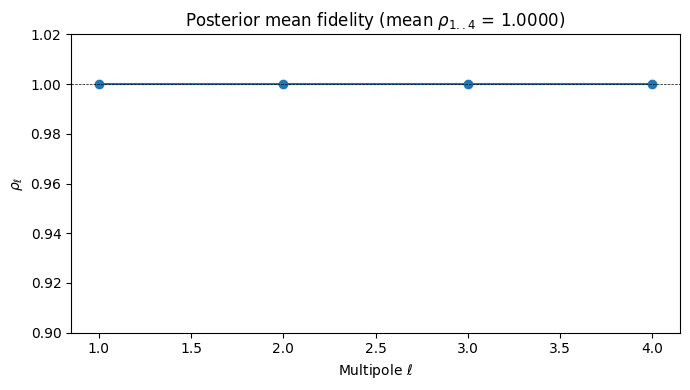

In [7]:
true_alm = np.asarray(sky.mapalm[0])
cl_t = hp.alm2cl(true_alm)
cl_r = hp.alm2cl(post_mean.astype(np.complex128))
cl_c = hp.alm2cl(true_alm, post_mean.astype(np.complex128))
rho = cl_c / np.sqrt(cl_t * cl_r + 1e-30)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(LMAX + 1)[1:], rho[1:LMAX+1], 'o-', ms=6)
ax.axhline(1, color='k', lw=0.5, ls='--')
ax.set_xlabel(r"Multipole $\ell$"); ax.set_ylabel(r"$\rho_\ell$")
ax.set_title(f"Posterior mean fidelity (mean $\\rho_{{1..{LMAX}}}$ = {np.nanmean(rho[1:LMAX+1]):.4f})")
ax.set_ylim(0.9, 1.02); plt.tight_layout()

## Posterior uncertainty on $a_{\ell 0}$

Real monopole/dipole components with one-sigma bands from the chain.

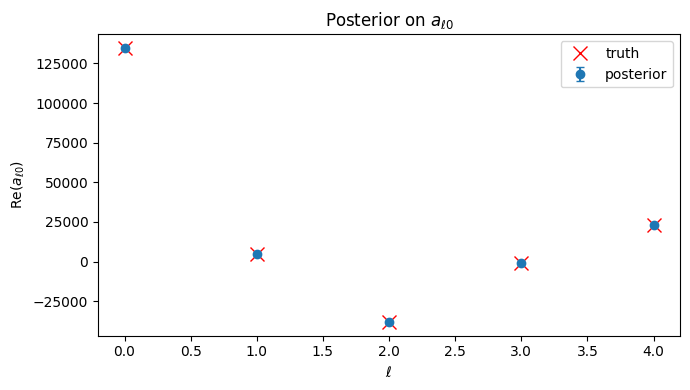

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ells = np.arange(LMAX + 1)
vals = np.array([samp[:, hp.Alm.getidx(LMAX, l, 0)].real for l in ells])    # (lmax+1, N)
mean = vals.mean(axis=1); stdv = vals.std(axis=1)
truth = np.array([true_alm[hp.Alm.getidx(LMAX, l, 0)].real for l in ells])
ax.errorbar(ells, mean, yerr=stdv, fmt='o', label='posterior', capsize=3)
ax.plot(ells, truth, 'rx', ms=10, label='truth')
ax.set_xlabel(r"$\ell$"); ax.set_ylabel(r"$\mathrm{Re}(a_{\ell 0})$")
ax.set_title("Posterior on $a_{\\ell 0}$")
ax.legend(); plt.tight_layout()

## Notes

- For a purely Gaussian posterior, NUTS is overkill: a single CG solve gives the
  MAP *and* the Cholesky of the posterior covariance (via `method='direct'`), from
  which independent draws are free. This notebook exists to validate the sampler
  and to serve as a template for non-Gaussian extensions (nonlinear foregrounds,
  $T_\text{sys}$ sampling, beam-parameter marginalization), where gradient MCMC is
  the right tool.